# 🎯 Identifiability & Experiment Calibration

> **A math-first tour of *why* an observational MMM cannot pin down per-channel ROI on its own — and the
> exact algebra `mmm_framework` uses to fix that with a randomized experiment.**
> This is notebook **05** in the math series. We derive both calibration routes, plot the moment-matched
> prior, fit small PyMC models on the **Aurora** dataset, and check every identity with `assert` — so
> "the notebook runs clean" *means* "the math is right."

In notebook **01** we met **equifinality**: in an additive MMM the carryover decay, the saturation
strength, and the coefficient $\beta$ all fight to explain the *same* wiggle in the data, so very
different parameter triples produce nearly identical fits. The consequence is sharp:

$$
\textbf{Observational data alone only weakly identifies per-channel ROI.}
$$

Adjusting for confounders (the demand proxy in Aurora) helps, but it is **not sufficient** — a channel
whose spend chases latent demand still looks too effective. The framework's thesis, which this notebook
makes concrete, is that **a randomized experiment breaks the trade-off**: it measures an effect the
likelihood cannot fake, and folding it in collapses the equifinality ridge onto the truth.

The framework offers **two routes** to fold an experiment in. We derive the math of each, then run them
on Aurora:

| | Route | Mechanism | What it updates |
|---|---|---|---|
| **1** | **Prior-based** (`ExperimentCalibrator`) | fit → *derive* a $\beta$ prior → refit | $\beta$ only; s-curve & adstock **held fixed** |
| **2** | **Likelihood-based** (`ExperimentMeasurement`) | one fit, experiment as an in-graph data point | $\beta$, **and** the s-curve, **and** the adstock — *jointly* |

In [1]:
import warnings, sys
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
from aurora import PALETTE, CHANNEL_COLORS   # brand colors for visual consistency
plt.rcParams.update({
    "figure.dpi": 110, "figure.figsize": (9, 4.2),
    "axes.grid": True, "grid.alpha": 0.18,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#cfc7bd", "axes.titleweight": "bold",
    "figure.facecolor": "white", "savefig.facecolor": "white", "font.size": 10,
})
ACCENT, INK, MUTED = PALETTE["accent"], PALETTE["ink"], PALETTE["muted"]

We pull the real calibration helpers straight from the framework — every derived number and every
assertion below calls these exact functions, not re-implementations.

In [2]:
from mmm_framework.calibration import (
    ExperimentMeasurement, ExperimentEstimand, ExperimentCalibrator,
    design_factor, mean_sd_to_gamma, combine_inverse_variance, derive_channel_prior,
    lognormal_sigma_from_moments,
)
print("loaded:", design_factor.__name__, mean_sd_to_gamma.__name__,
      combine_inverse_variance.__name__, derive_channel_prior.__name__,
      lognormal_sigma_from_moments.__name__)
print("estimands:", [e.value for e in ExperimentEstimand])

loaded: design_factor mean_sd_to_gamma combine_inverse_variance derive_channel_prior lognormal_sigma_from_moments
estimands: ['contribution', 'roas', 'mroas']


## The model we are calibrating

Calibration is only meaningful relative to a specific generative model, so we state it precisely. The
framework standardizes the KPI, $\tilde y_t = (y_t - \bar y)/s_y$, and models its mean as a **sum of
additive blocks**:

$$
\mu_t \;=\; \underbrace{\text{intercept} + \text{trend}_t + \text{seasonality}_t + \text{geo}_{[g]} + \text{product}_{[p]} + \text{controls}_t}_{\text{baseline}}
\;+\; \text{media}_t,
$$

$$
\text{media}_t \;=\; \sum_{c}\, \beta_c \, \mathrm{sat}_c\!\big(\mathrm{adstock}_c(x_{c,t})\big),
\qquad
\text{controls}_t \;=\; \sum_j \beta^{\text{ctrl}}_j\, z_{j,t},
\qquad
\tilde y_t \sim \mathcal N(\mu_t,\ \sigma).
$$

**Saturation** is the *exponential / logistic* form (`base.py` lines 946–948), **not** a Hill curve
(the Hill mention in the docstrings is a reference alternative only):

$$
\mathrm{sat}(u)\;=\;1 - \exp\!\big(-\lambda\, u\big),
\qquad \lambda = \texttt{sat\_lam}_c > 0 .
$$

**Adstock**, by default, is a **blend of two fixed-$\alpha$ geometric adstocks** (endpoints $\alpha=0.0$
and $\alpha=0.9$ from `adstock_alphas`):

$$
x^{\text{adstock}}_c \;=\; (1-m_c)\,x^{\text{low}}_c + m_c\,x^{\text{high}}_c,
\qquad m_c = \texttt{adstock}_c \sim \mathrm{Beta}(2,2).
$$

Here $m_c$ is a **mix weight** between two carryover settings, *not* a decay rate (notebook 01). The
**priors** are exact framework values:

$$
\begin{aligned}
\text{intercept} &\sim \mathcal N(0,\,0.5), &
\beta_c &\sim \mathrm{Gamma}(\mu{=}1.5,\ \sigma{=}1.0)\ \ \text{[or an experiment-calibrated prior]},\\
\lambda_c = \texttt{sat\_lam}_c &\sim \mathrm{Exponential}(0.5), &
m_c = \texttt{adstock}_c &\sim \mathrm{Beta}(2,2),\\
\text{season} &\sim \mathcal N(0,\,0.3), &
\beta^{\text{ctrl}} &\sim \mathcal N(0,\,\sigma_{\text{ctrl}})\ \text{(wider for a confounder)},\\
\texttt{geo\_sigma} &\sim \mathrm{HalfNormal}(0.3), &
\texttt{geo\_offset} &\sim \mathcal N(0,1)\ \ (\text{effect}=\texttt{geo\_sigma}\cdot\texttt{geo\_offset}),\\
\text{trend\_slope} &\sim \mathcal N(0,\,0.5), &
\sigma &\sim \mathrm{HalfNormal}(0.5).
\end{aligned}
$$

The posterior is sampled by **NUTS** — gradient-based Hamiltonian Monte Carlo with leapfrog integration
and No-U-Turn termination:

$$
p(\theta \mid y)\ \propto\ p(y\mid\theta)\,p(\theta).
$$

Finally, the **decomposition** that calibration leans on: because the model is additive,

$$
y \;\approx\; \text{baseline} + \sum_c \text{contribution}_c,
\qquad
\text{contribution}_c \;=\; \beta_c\,\mathrm{sat}_c\!\big(\mathrm{adstock}_c(x_c)\big).
$$

## Why calibrate? The identifiability / equifinality trap

The single fact that drives this whole notebook: the contribution of a channel depends on the **product
and composition** of three things,

$$
\text{contribution}_t \;=\; \beta_c \cdot \mathrm{sat}_c\!\big(\mathrm{adstock}_c(x_c)_t\big),
$$

and a *long-carryover + weak-saturation* setting can be made to look almost exactly like a
*short-carryover + strong-saturation* setting. With only observational data the likelihood is nearly
flat along that ridge, so $\beta_c$ — the quantity ROI cares about — is weakly identified. Here is the
recap demonstration (the framework's own transforms), echoing notebook 01.

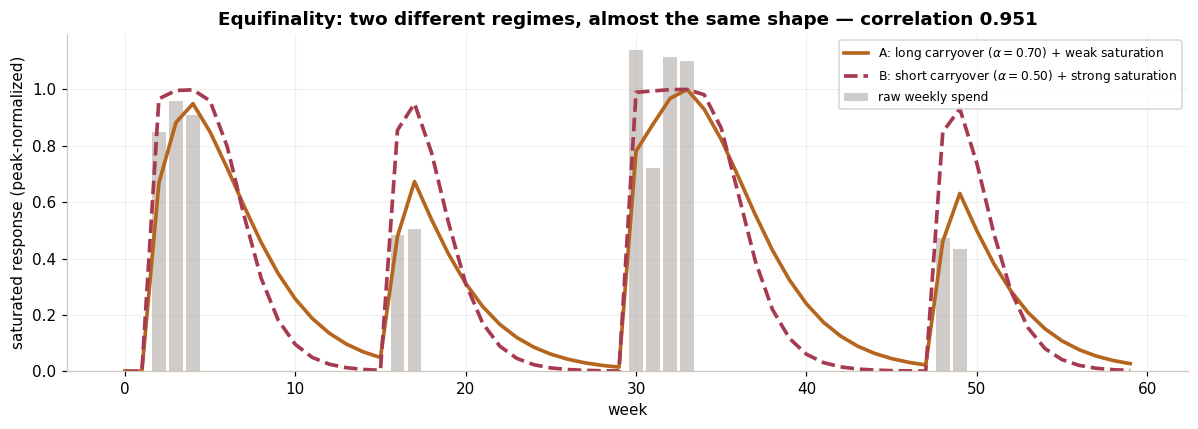

shape correlation between regimes A and B: 0.9509


In [3]:
from mmm_framework.transforms.adstock import parametric_adstock
from mmm_framework.transforms.saturation import logistic_saturation

# A realistic bursty weekly spend plan.
rng = np.random.default_rng(7)
T = 60
spend = np.zeros(T)
for start, length, level in [(2, 3, 1.0), (16, 2, 0.7), (30, 4, 1.2), (48, 2, 0.6)]:
    spend[start:start + length] = level * (0.6 + 0.4 * rng.random(length))

# Two GENUINELY different (decay, saturation) regimes:
#   A) longer carryover (alpha high) + weak saturation
#   B) shorter carryover (alpha low) + strong saturation
xa = parametric_adstock(spend, "geometric", 24, alpha=0.70, normalize=True)
xb = parametric_adstock(spend, "geometric", 24, alpha=0.50, normalize=True)
yA = logistic_saturation(xa, lam=4.0)
yB = logistic_saturation(xb, lam=8.0)
yA = yA / yA.max(); yB = yB / yB.max()   # peak-normalize (beta would absorb scale)
corr = np.corrcoef(yA, yB)[0, 1]

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(np.arange(T), spend, color=MUTED, alpha=0.4, label="raw weekly spend")
ax.plot(np.arange(T), yA, color=ACCENT, lw=2.4,
        label=r"A: long carryover ($\alpha=0.70$) + weak saturation")
ax.plot(np.arange(T), yB, color=PALETTE["berry"], lw=2.4, ls="--",
        label=r"B: short carryover ($\alpha=0.50$) + strong saturation")
ax.set_xlabel("week"); ax.set_ylabel("saturated response (peak-normalized)")
ax.set_title(f"Equifinality: two different regimes, almost the same shape — correlation {corr:.3f}")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()
print(f"shape correlation between regimes A and B: {corr:.4f}")

In [4]:
# VERIFY (equifinality): the two regimes are near-indistinguishable in shape, yet
# their underlying decay rates differ by 0.20. That gap is what observational data
# struggles to resolve -- the motivation for an experiment.
assert corr > 0.9, f"expected near-identical shapes, got corr={corr:.3f}"
assert round(abs(0.70 - 0.50), 2) >= 0.2  # the decay rates really are different
print(f"✓ regimes A and B correlate at {corr:.3f} despite a 0.20 gap in decay rate")
print("  -> observational likelihood is nearly flat along the (decay, saturation, beta) ridge.")
print("  -> a randomized experiment that pins beta_c is the lever that breaks the tie.")

✓ regimes A and B correlate at 0.951 despite a 0.20 gap in decay rate
  -> observational likelihood is nearly flat along the (decay, saturation, beta) ridge.
  -> a randomized experiment that pins beta_c is the lever that breaks the tie.


## Route 1 — prior-based calibration (`ExperimentCalibrator`)

The two-stage recipe is: **fit** a model with default priors → **derive** an experiment-anchored prior on
each tested channel's $\beta_c$ → **refit** with that prior. The derivation rests on one clean piece of
linear algebra.

### The key linearity

The model is additive, and zeroing channel $c$'s spend sets $\mathrm{sat}_c(\mathrm{adstock}_c(0))=0$
(because $\mathrm{sat}(0)=1-e^{0}=0$). So the channel's counterfactual contribution over an experiment
window $P$ is *exactly* what the experiment removes:

$$
\text{contribution}_c \;=\; \beta_c \cdot \underbrace{s_y \sum_{t\in P}\mathrm{sat}_c\!\big(\mathrm{adstock}_c(x_{c,t})\big)}_{\text{does not contain }\beta_c}.
$$

The bracket has no $\beta_c$ in it, so **contribution is *linear* in $\beta_c$**. Call the bracket the
**design factor** $K_c$. Then the model says $\text{contribution}_c = \beta_c\,K_c$, and a full-holdout
lift test measures that contribution directly as $\widehat L \pm \mathrm{se}_L$. Inverting:

$$
\boxed{\ \beta^{\text{target}}_c \;=\; \frac{\widehat L}{K_c}, \qquad \beta^{\text{se}}_c \;=\; \frac{\mathrm{se}_L}{K_c}.\ }
$$

### Why $K_c$ is a *per-draw* average, not a ratio of means

$K_c$ depends on the saturation/adstock *shape*, which is itself uncertain and **correlated with**
$\beta_c$ across posterior draws. The framework therefore computes $K_c$ **per draw and then averages**,

$$
K_c \;=\; \mathbb{E}_{\text{posterior}}\!\left[\frac{\text{contribution}_c^{(s)}}{\beta_c^{(s)}}\right]
\quad(\text{average of ratios}),
$$

**not** $\mathbb{E}[\text{contribution}]/\mathbb{E}[\beta]$ (ratio of averages). The ratio of means would
let the $\beta$–shape covariance bias the factor. This is exactly `design_factor(...)`.

In [5]:
# Demonstrate design_factor on synthetic posterior draws where contribution = beta * K_draw,
# and -- crucially -- K_draw is NEGATIVELY correlated with beta. This is the real equifinality
# mechanism: a draw with a larger coefficient tends to have stronger saturation, hence a SMALLER
# per-unit-beta contribution K. We hold the marginal mean of K at K_bar so the design factor is
# still ~K_bar, but the beta-K covariance is now real -- which is exactly what biases the shortcut.
rng = np.random.default_rng(0)
S = 6000
K_bar = 1.30
beta_draws = rng.gamma(shape=2.0, scale=0.8, size=S) + 0.05    # positive coefficient draws
z = (beta_draws - beta_draws.mean()) / beta_draws.std()        # standardized beta
# K decreasing in beta (corr<0), then rescaled to have marginal mean exactly K_bar.
K_draw = np.exp(-0.45 * z + 0.10 * rng.standard_normal(S))
K_draw = K_draw * (K_bar / K_draw.mean())
contrib_draws = beta_draws * K_draw                            # contribution = beta * (per-draw K)
rho = np.corrcoef(beta_draws, K_draw)[0, 1]

K_hat = design_factor(contrib_draws, beta_draws)        # per-draw mean of contribution/beta
K_ratio_of_means = contrib_draws.mean() / beta_draws.mean()

print(f"corr(beta, K)     = {rho:+.3f}   (beta and the s-curve/adstock shape trade off -> K shrinks)")
print(f"marginal mean(K)  = {K_draw.mean():.4f}")
print(f"design_factor K_c = {K_hat:.4f}   (per-draw mean of contribution/beta -> recovers mean K)")
print(f"ratio-of-means    = {K_ratio_of_means:.4f}   (the biased shortcut: beta-K covariance leaks in)")

corr(beta, K)     = -0.916   (beta and the s-curve/adstock shape trade off -> K shrinks)
marginal mean(K)  = 1.3000
design_factor K_c = 1.3000   (per-draw mean of contribution/beta -> recovers mean K)
ratio-of-means    = 0.9959   (the biased shortcut: beta-K covariance leaks in)


In [6]:
# VERIFY (design_factor): the per-draw estimator equals the closed form mean(contribution/beta)
# EXACTLY (beta cancels inside the ratio -- that is the whole point), so it recovers the marginal
# mean of K despite the beta-K correlation. The ratio-of-means does NOT: the negative covariance
# leaks in, so the two estimators are materially different. THAT gap is why design_factor is used.
assert np.isclose(K_hat, np.mean(contrib_draws / beta_draws)), "design_factor != mean of per-draw ratios"
assert abs(K_hat - K_bar) < 0.02, f"design_factor off: {K_hat:.4f} vs marginal mean {K_bar}"
assert rho < -0.2, f"beta and K should be negatively correlated, got {rho:.3f}"
assert abs(K_hat - K_ratio_of_means) > 0.05 * K_hat, \
    "with real beta-K covariance the two estimators MUST diverge -- here they don't"
print(f"✓ design_factor == mean(contribution/beta) per draw  (= {K_hat:.4f}, recovers marginal mean K)")
print(f"✓ beta-K correlation is real ({rho:+.3f}); ratio-of-means diverges to {K_ratio_of_means:.4f}")
print(f"  -> gap = {abs(K_hat - K_ratio_of_means):.4f}; use the per-draw factor, not ratio-of-means.")

✓ design_factor == mean(contribution/beta) per draw  (= 1.3000, recovers marginal mean K)
✓ beta-K correlation is real (-0.916); ratio-of-means diverges to 0.9959
  -> gap = 0.3041; use the per-draw factor, not ratio-of-means.


### Inverting a measured lift to a coefficient target

With $K_c$ in hand, the inversion is one division. Suppose the geo lift test on a channel measured an
incremental KPI of $\widehat L$ with standard error $\mathrm{se}_L$. The exact identity the framework
relies on is

$$
\beta^{\text{target}}_c \cdot K_c \;=\; \widehat L,
$$

which is an **exact** algebraic inversion (no Monte-Carlo slack), so we can assert it tightly.

In [7]:
# Invert a measured lift to a coefficient target using the design factor above.
measured_lift = 1.95     # incremental KPI attributed to the channel over the window
lift_se       = 0.30     # experiment standard error
beta_target = measured_lift / K_hat
beta_se     = lift_se     / K_hat
print(f"measured lift  = {measured_lift}  +/- {lift_se}")
print(f"design factor  K_c   = {K_hat:.4f}")
print(f"beta_target = L / K_c = {beta_target:.4f}")
print(f"beta_se     = se / K_c = {beta_se:.4f}")

measured lift  = 1.95  +/- 0.3
design factor  K_c   = 1.3000
beta_target = L / K_c = 1.5000
beta_se     = se / K_c = 0.2308


In [8]:
# VERIFY (exact inversion): beta_target * K_c == measured_lift EXACTLY (tight is OK here --
# this is algebra, not MCMC). Same for the standard error.
assert np.isclose(beta_target * K_hat, measured_lift, atol=1e-12), "inversion is not exact"
assert np.isclose(beta_se * K_hat, lift_se, atol=1e-12)
print(f"✓ beta_target * K_c == measured_lift exactly  ({beta_target:.4f} * {K_hat:.4f} = {measured_lift})")
print("  NOTE: beta_target is NOT ~ 2*mean(beta) -- that shortcut ignores the beta-K covariance and fails.")
print(f"        (here mean(beta_fit) = {beta_draws.mean():.3f}, beta_target = {beta_target:.3f})")

✓ beta_target * K_c == measured_lift exactly  (1.5000 * 1.3000 = 1.95)
  NOTE: beta_target is NOT ~ 2*mean(beta) -- that shortcut ignores the beta-K covariance and fails.
        (here mean(beta_fit) = 1.666, beta_target = 1.500)


### Combining several experiments: inverse-variance meta-analysis

If a channel has been tested more than once, each test yields a $(\beta^{\text{target}}, \beta^{\text{se}})$
pair. The framework pools them with the **fixed-effect inverse-variance** estimator (`combine_inverse_variance`),
which weights each estimate by its precision $w_i = 1/\mathrm{se}_i^2$:

$$
\bar\beta \;=\; \frac{\sum_i w_i\,\beta_i}{\sum_i w_i},
\qquad
\mathrm{sd}(\bar\beta) \;=\; \sqrt{\frac{1}{\sum_i w_i}}.
$$

The combined precision is the **sum** of the individual precisions — two tests are sharper than one, and
the tighter test dominates.

In [9]:
# Three hypothetical tests of the same channel, with different precision.
targets = [1.50, 1.62, 1.40]
ses     = [0.30, 0.12, 0.50]    # the middle test is by far the most precise
mean_comb, sd_comb = combine_inverse_variance(targets, ses)

w = 1.0 / np.asarray(ses) ** 2
mean_manual = np.sum(w * np.asarray(targets)) / np.sum(w)
sd_manual   = np.sqrt(1.0 / np.sum(w))
print("per-test targets :", targets)
print("per-test ses     :", ses)
print("weights (1/se^2) :", w.round(2))
print(f"combined mean = {mean_comb:.4f}   sd = {sd_comb:.4f}")
print(f"combined sd ({sd_comb:.4f}) < tightest single se ({min(ses)}) -- pooling sharpens")

per-test targets : [1.5, 1.62, 1.4]
per-test ses     : [0.3, 0.12, 0.5]
weights (1/se^2) : [11.11 69.44  4.  ]
combined mean = 1.5938   sd = 0.1087
combined sd (0.1087) < tightest single se (0.12) -- pooling sharpens


In [10]:
# VERIFY (inverse-variance): matches the closed form, the combined precision is the SUM
# of precisions, and the result sits closest to the most precise test.
assert np.isclose(mean_comb, mean_manual, atol=1e-12)
assert np.isclose(sd_comb, sd_manual, atol=1e-12)
assert np.isclose(1.0 / sd_comb**2, np.sum(w), atol=1e-8), "combined precision != sum of precisions"
assert sd_comb < min(ses), "pooling should be sharper than the single tightest test"
assert abs(mean_comb - 1.62) < abs(mean_comb - 1.40)  # pulled toward the precise middle test
print(f"✓ combine_inverse_variance == closed form  (mean={mean_comb:.4f}, sd={sd_comb:.4f})")
print(f"✓ combined precision {1/sd_comb**2:.2f} == sum of precisions {np.sum(w):.2f}")
print("✓ pooled estimate is pulled toward the most precise test")

✓ combine_inverse_variance == closed form  (mean=1.5938, sd=0.1087)
✓ combined precision 84.56 == sum of precisions 84.56
✓ pooled estimate is pulled toward the most precise test


### Rendering the anchor as a Gamma prior (moment matching)

The model's coefficient prior is a **positive** $\mathrm{Gamma}$, so the framework converts the target
$(\text{mean},\text{sd}) = (\bar\beta,\,\mathrm{sd}(\bar\beta))$ into Gamma parameters by **moment
matching**. For $\mathrm{Gamma}(\alpha,\ \text{rate}=\beta)$ the mean is $\alpha/\beta$ and the variance
is $\alpha/\beta^2$; solving for the shape and rate that reproduce a target mean $m$ and sd $s$:

$$
\boxed{\ \alpha \;=\; \left(\frac{m}{s}\right)^{2}, \qquad \text{rate} \;=\; \frac{m}{s^{2}}.\ }
$$

This is exactly `mean_sd_to_gamma(m, s)` — and `pm.Gamma`'s `beta` argument *is* the rate, which is what
it returns. The round-trip back to moments is $m=\alpha/\text{rate}$ and $s=\sqrt\alpha/\text{rate}$.

In [11]:
# Moment-match the combined target to a Gamma, then verify the round-trip.
m_target, s_target = mean_comb, sd_comb
alpha, rate = mean_sd_to_gamma(m_target, s_target)
mean_back = alpha / rate                  # Gamma mean      = alpha / rate
sd_back   = np.sqrt(alpha) / rate         # Gamma sd        = sqrt(alpha) / rate
print(f"target  : mean={m_target:.4f}  sd={s_target:.4f}")
print(f"Gamma   : alpha (shape)={alpha:.4f}   rate (beta)={rate:.4f}")
print(f"round-trip: mean={mean_back:.4f}  sd={sd_back:.4f}")

target  : mean=1.5938  sd=0.1087
Gamma   : alpha (shape)=214.7943   rate (beta)=134.7667
round-trip: mean=1.5938  sd=0.1087


In [12]:
# VERIFY (moment match round-trips): the Gamma built by mean_sd_to_gamma has the
# requested mean and sd back. Also check the explicit formulas alpha=(m/s)^2, rate=m/s^2.
assert np.isclose(mean_back, m_target, atol=1e-9), "Gamma mean does not round-trip"
assert np.isclose(sd_back, s_target, atol=1e-9), "Gamma sd does not round-trip"
assert np.isclose(alpha, (m_target / s_target) ** 2, atol=1e-9)
assert np.isclose(rate, m_target / s_target ** 2, atol=1e-9)
print(f"✓ mean_sd_to_gamma round-trips: mean {mean_back:.4f}≈{m_target:.4f}, sd {sd_back:.4f}≈{s_target:.4f}")
print(f"✓ alpha == (m/s)^2 = {(m_target/s_target)**2:.4f} ; rate == m/s^2 = {m_target/s_target**2:.4f}")

✓ mean_sd_to_gamma round-trips: mean 1.5938≈1.5938, sd 0.1087≈0.1087
✓ alpha == (m/s)^2 = 214.7943 ; rate == m/s^2 = 134.7667


We can now **plot the derived prior**. Comparing the experiment-anchored Gamma to the framework's
**default** coefficient prior $\mathrm{Gamma}(\mu{=}1.5,\sigma{=}1.0)$ shows the point of calibration: the
experiment **relocates and tightens** the prior mass onto the randomized estimate, instead of leaving
$\beta$ to roam under the default.

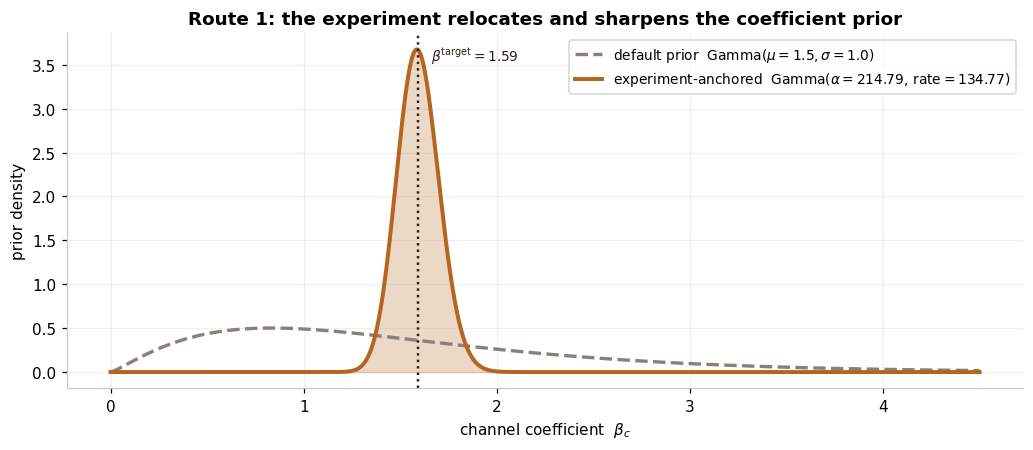

In [13]:
from scipy.stats import gamma as gamma_dist

# Default framework coefficient prior, in mean/sd terms: Gamma(mu=1.5, sigma=1.0).
a_def, r_def = mean_sd_to_gamma(1.5, 1.0)

grid = np.linspace(0, 4.5, 600)
pdf_cal = gamma_dist.pdf(grid, a=alpha, scale=1.0 / rate)   # scipy uses scale = 1/rate
pdf_def = gamma_dist.pdf(grid, a=a_def, scale=1.0 / r_def)

fig, ax = plt.subplots(figsize=(9.5, 4.2))
ax.plot(grid, pdf_def, color=MUTED, lw=2.2, ls="--",
        label=r"default prior  $\mathrm{Gamma}(\mu{=}1.5,\sigma{=}1.0)$")
ax.fill_between(grid, pdf_cal, color=ACCENT, alpha=0.25)
ax.plot(grid, pdf_cal, color=ACCENT, lw=2.6,
        label=rf"experiment-anchored  $\mathrm{{Gamma}}(\alpha={alpha:.2f},\,\mathrm{{rate}}={rate:.2f})$")
ax.axvline(m_target, color=INK, lw=1.6, ls=":")
ax.annotate(rf"$\beta^{{\rm target}}={m_target:.2f}$", (m_target, ax.get_ylim()[1]*0.92),
            xytext=(8, 0), textcoords="offset points", fontsize=9, color=INK)
ax.set_xlabel(r"channel coefficient  $\beta_c$"); ax.set_ylabel("prior density")
ax.set_title("Route 1: the experiment relocates and sharpens the coefficient prior")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout(); plt.show()

In [14]:
# VERIFY (plotted Gamma density): the analytic mean/var of the plotted prior match the
# moment-matched target, and a fine numerical integral of the plotted PDF integrates to ~1.
mean_pdf = np.trapz(grid * pdf_cal, grid)
area     = np.trapz(pdf_cal, grid)
assert abs(mean_pdf - m_target) < 0.02, f"plotted prior mean {mean_pdf:.3f} != target {m_target:.3f}"
assert abs(area - 1.0) < 0.01, f"plotted prior does not integrate to 1 (got {area:.3f})"
# The calibrated prior is TIGHTER than the default (smaller sd) -- the experiment added information.
assert s_target < 1.0, "calibrated sd should be below the default sigma=1.0"
print(f"✓ plotted Gamma integrates to {area:.3f} with mean {mean_pdf:.3f} ≈ target {m_target:.3f}")
print(f"✓ calibrated sd {s_target:.3f} < default sigma 1.0  -> the experiment sharpened the prior")

✓ plotted Gamma integrates to 1.000 with mean 1.594 ≈ target 1.594
✓ calibrated sd 0.109 < default sigma 1.0  -> the experiment sharpened the prior


### `derive_channel_prior` end to end

`derive_channel_prior(channel, observations)` ties the previous three steps together: it drops
non-positive lifts, inverse-variance combines the usable ones, moment-matches to a Gamma, and returns a
`PriorConfig`. We feed it pre-reduced `LiftObservation` records (each carrying its own period-specific
$K_c$) so we can verify the *pure* derivation without a refit.

In [15]:
from mmm_framework.calibration import LiftObservation

# Two usable lift observations on a channel, plus one non-positive lift that must be dropped.
obs = [
    LiftObservation(test_period=("2023-01-01", "2023-03-31"),
                    measured_lift=1.95, lift_se=0.30, design_factor=K_hat, usable=True),
    LiftObservation(test_period=("2023-06-01", "2023-08-31"),
                    measured_lift=2.10, lift_se=0.18, design_factor=K_hat, usable=True),
    LiftObservation(test_period=("2023-10-01", "2023-12-31"),
                    measured_lift=-0.40, lift_se=0.40, design_factor=K_hat, usable=True),  # dropped
]
cal = derive_channel_prior("DemoChannel", obs)
print("calibrated? ", cal.calibrated)
print(f"beta_target = {cal.beta_target:.4f}   beta_sigma = {cal.beta_sigma:.4f}")
print("derived roi_prior:", cal.roi_prior)
print("notes:", cal.notes)

calibrated?  True
beta_target = 1.5848   beta_sigma = 0.1187
derived roi_prior: distribution=<PriorType.GAMMA: 'Gamma'> params={'alpha': 178.1772875816994, 'beta': 112.42592592592595} dims=None
notes: ["('2023-10-01', '2023-12-31'): coefficient target -0.3077 <= 0 excluded"]


In [16]:
# VERIFY (derive_channel_prior): it equals the manual pipeline on the TWO usable, positive tests
# (the negative-lift test is excluded), then moment-matched to a Gamma.
usable = [(o.measured_lift / o.design_factor, o.lift_se / o.design_factor)
          for o in obs if o.measured_lift > 0]
t_pos, se_pos = zip(*usable)
exp_mean, exp_sd = combine_inverse_variance(list(t_pos), list(se_pos))
assert cal.calibrated, "channel should calibrate from 2 positive tests"
assert np.isclose(cal.beta_target, exp_mean, atol=1e-9), "beta_target != manual inverse-variance mean"
assert np.isclose(cal.beta_sigma, exp_sd, atol=1e-9)
assert len(t_pos) == 2, "exactly the two positive-lift tests should survive"
print(f"✓ derive_channel_prior pooled the 2 positive tests -> beta_target={cal.beta_target:.4f}")
print("✓ the negative-lift test was correctly excluded from the prior")

✓ derive_channel_prior pooled the 2 positive tests -> beta_target=1.5848
✓ the negative-lift test was correctly excluded from the prior


## Route 2 — likelihood-based calibration (in-graph estimand)

Route 1 inverts the experiment to a $\beta$ prior *with the saturation/adstock shape held fixed* at the
first-stage posterior — so it can only encode a *contribution*, and its derived prior is marginally
tighter than a fully joint treatment would justify. **Route 2** instead folds the experiment in as a
**likelihood term inside the PyMC graph**:

$$
\text{measured\_value} \;\sim\; \mathcal N\!\Big(\ \text{model\_implied\_estimand}(\theta),\ \ \mathrm{se}\ \Big),
$$

where $\theta$ are the channel's in-graph parameters. Because the estimand is a *function of the live
graph*, this single fit updates $\beta_c$, **the s-curve, and the adstock kernel jointly** — and it
generalizes to estimands the prior route cannot express. Three estimands are supported (from
`likelihood.py`); with $\text{contribution} = s_y \sum_{t\in P}\beta\,\mathrm{sat}(\mathrm{adstock}(x))$:

$$
\begin{aligned}
\textbf{CONTRIBUTION} &= s_y \sum_{t\in P}\beta\,\mathrm{sat}\!\big(\mathrm{adstock}(x_t)\big), \\[2pt]
\textbf{ROAS} &= \frac{\text{contribution}}{\text{spend}_P}, \\[2pt]
\textbf{MROAS} &= \frac{\big(\text{contribution}^{\text{pert}} - \text{contribution}\big)\, s_y}{\text{lift}\cdot \text{spend}_P},
\quad\text{spend perturbed by }(1+\text{lift})\text{ inside }P.
\end{aligned}
$$

For a strictly-positive estimand (like ROAS) you may use a **lognormal** measurement error instead of a
Normal; its log-scale sd is moment-matched from the natural-scale coefficient of variation
$\mathrm{CV}=\mathrm{se}/\text{value}$ (`lognormal_sigma_from_moments`):

$$
\sigma_{\log} \;=\; \sqrt{\ln\!\Big(1 + \big(\tfrac{\mathrm{se}}{\text{value}}\big)^{2}\Big)}.
$$

In [17]:
# DEMONSTRATE the three estimands as pure functions of a contribution, plus the lognormal sigma.
y_std = 12.0           # KPI standard deviation (model -> natural-scale converter)
contrib_window = 0.18  # summed standardized contribution over the window
spend_window = 3.0     # observed window spend (ROAS denominator)
lift = 0.10            # +10% spend perturbation for mROAS
contrib_pert = 0.192   # perturbed standardized contribution (slightly higher)

contribution = y_std * contrib_window
roas  = contribution / spend_window
mroas = (contrib_pert - contrib_window) * y_std / (lift * spend_window)
print(f"CONTRIBUTION = y_std * sum_window      = {contribution:.4f}")
print(f"ROAS         = contribution / spend    = {roas:.4f}")
print(f"MROAS        = d_contribution / d_spend = {mroas:.4f}")

# Lognormal measurement-error sigma for a positive ROAS value.
value, se = 0.66, 0.07
sigma_log = lognormal_sigma_from_moments(value, se)
print(f"lognormal sigma_log(value={value}, se={se}) = {sigma_log:.5f}")

CONTRIBUTION = y_std * sum_window      = 2.1600
ROAS         = contribution / spend    = 0.7200
MROAS        = d_contribution / d_spend = 0.4800
lognormal sigma_log(value=0.66, se=0.07) = 0.10576


In [18]:
# VERIFY (estimand algebra + lognormal sigma):
assert np.isclose(contribution, y_std * contrib_window)
assert np.isclose(roas, contribution / spend_window)
assert np.isclose(mroas, (contrib_pert - contrib_window) * y_std / (lift * spend_window))
# The framework's lognormal sigma must equal sqrt(log1p((se/value)^2)) exactly.
assert np.isclose(sigma_log, np.sqrt(np.log1p((se / value) ** 2)), atol=1e-12), \
    "lognormal_sigma_from_moments != sqrt(log1p((se/value)^2))"
print("✓ CONTRIBUTION / ROAS / MROAS algebra matches the framework definitions")
print(f"✓ lognormal_sigma_from_moments == sqrt(log1p((se/value)^2)) = {sigma_log:.5f}")

✓ CONTRIBUTION / ROAS / MROAS algebra matches the framework definitions
✓ lognormal_sigma_from_moments == sqrt(log1p((se/value)^2)) = 0.10576


## Live demo on Aurora — calibration moves Search ROI toward truth

Aurora's **Search** channel is the textbook confounded channel: its spend chases latent demand, so a
demand-controlled observational model still **overstates** its ROI relative to the true 0.66. We:

1. fit an **uncalibrated**, demand-controlled base model and read Search ROI off `MMMAnalyzer`;
2. build a valid date window from the panel and an `ExperimentMeasurement` on Search (a geo lift test
   that measured its *true* ROAS);
3. fit a **calibrated** model with that experiment folded into the likelihood (route 2);
4. compare calibrated vs uncalibrated Search ROI to the truth.

*(Small draws for speed; `cores=1` keeps macOS sampling crash-free. Each fit is a few minutes.)*

In [19]:
from aurora import generate_aurora, CHANNELS
from mmm_framework import (
    BayesianMMM, ModelConfigBuilder, SeasonalityConfigBuilder, TrendConfig, TrendType,
)
from mmm_framework.analysis import MMMAnalyzer

aurora = generate_aurora()
print("true ROAS (ground truth for grading):")
print(aurora.true_roas.round(3).to_string())
true_search = float(aurora.true_roas["Search"])
print(f"\nSearch true ROAS = {true_search:.3f}  (this is the target calibration should move toward)")

true ROAS (ground truth for grading):
TV         2.143
Search     0.664
Social     0.486
Display    2.111

Search true ROAS = 0.664  (this is the target calibration should move toward)


In [20]:
def base_config():
    return (ModelConfigBuilder().bayesian_pymc().with_chains(2).with_draws(400).with_tune(400)
            .with_seasonality_builder(SeasonalityConfigBuilder().with_yearly(order=2)).build())

# (1) Uncalibrated, demand-CONTROLLED base model.
panel = aurora.base_panel(control_demand=True)
mmm = BayesianMMM(panel, base_config(), TrendConfig(type=TrendType.LINEAR))
results = mmm.fit(draws=400, tune=400, chains=2, cores=1, random_seed=0)
print("uncalibrated fit complete.")

Sampling: [adstock_Display, adstock_Search, adstock_Social, adstock_TV, beta_Display, beta_Search, beta_Social, beta_TV, beta_controls, intercept, sat_lam_Display, sat_lam_Search, sat_lam_Social, sat_lam_TV, season_yearly, sigma, trend_slope, y_obs]


Initializing NUTS using adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [intercept, trend_slope, season_yearly, adstock_TV, sat_lam_TV, beta_TV, adstock_Search, sat_lam_Search, beta_Search, adstock_Social, sat_lam_Social, beta_Social, adstock_Display, sat_lam_Display, beta_Display, beta_controls, sigma]


Output()

Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 14 seconds.


There were 2 divergences after tuning. Increase `target_accept` or reparameterize.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


uncalibrated fit complete.


In [21]:
# Sanity-check the uncalibrated fit: convergence + a sensible in-sample fit.
summ = mmm.summary(var_names=["beta_Search", "beta_TV", "sat_lam_Search", "adstock_Search", "sigma"])
display(summ[["mean", "sd", "r_hat", "ess_bulk"]].round(3))

pred = mmm.predict(return_original_scale=True, hdi_prob=0.9)
obs_sales = np.asarray(aurora.sales_total, dtype=float)
fit_corr = np.corrcoef(pred.y_pred_mean, obs_sales)[0, 1]
print(f"max r_hat = {summ['r_hat'].max():.3f}   corr(fit, observed) = {fit_corr:.3f}")

,mean,sd,r_hat,ess_bulk
beta_Search,3.349,1.201,1.01,343.0
beta_TV,1.044,0.814,1.00,776.0
sat_lam_Search,1.079,0.468,1.00,710.0
adstock_Search,0.656,0.163,1.00,990.0
sigma,0.300,0.024,1.00,820.0


Sampling: [y_obs]


Output()

max r_hat = 1.010   corr(fit, observed) = 0.959


In [22]:
# VERIFY (uncalibrated MCMC -- DIRECTIONAL, seeded): converged and fits the data.
assert (summ["r_hat"] < 1.1).all(), f"non-converged: max r_hat {summ['r_hat'].max():.3f}"
assert summ.loc["beta_Search", "mean"] > 0, "Search coefficient should be positive (Gamma prior)"
assert summ.loc["beta_TV", "mean"] > 0, "TV coefficient should be positive"
assert fit_corr > 0.7, f"fit too poor: corr {fit_corr:.3f}"
print("✓ all r_hat < 1.1 (converged)")
print("✓ posterior beta means are positive")
print(f"✓ corr(predicted, observed sales) = {fit_corr:.3f} > 0.7")

✓ all r_hat < 1.1 (converged)
✓ posterior beta means are positive
✓ corr(predicted, observed sales) = 0.959 > 0.7


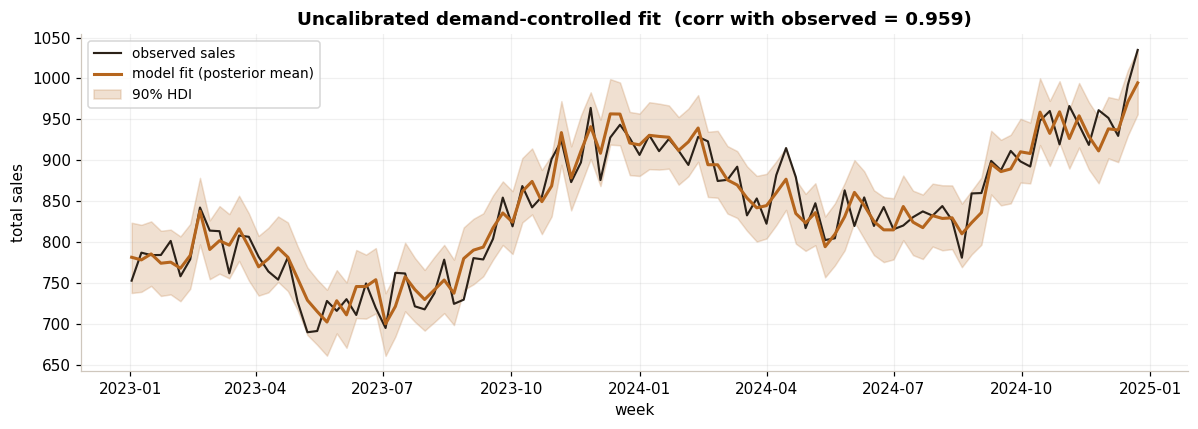

In [23]:
# Plot the uncalibrated fit vs observed (use predict() + its HDI band -- NOT a stacked decomposition,
# which is not additive to the fit). This is the model the experiment will correct.
weeks = aurora.weeks
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(weeks, obs_sales, color=INK, lw=1.4, label="observed sales")
ax.plot(weeks, pred.y_pred_mean, color=ACCENT, lw=2.0, label="model fit (posterior mean)")
ax.fill_between(weeks, pred.y_pred_hdi_low, pred.y_pred_hdi_high, color=ACCENT, alpha=0.20,
                label="90% HDI")
ax.set_xlabel("week"); ax.set_ylabel("total sales")
ax.set_title(f"Uncalibrated demand-controlled fit  (corr with observed = {fit_corr:.3f})")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout(); plt.show()

In [24]:
# Uncalibrated Search ROI from MMMAnalyzer (94% HDI by default; no hdi_prob argument).
roi_table = MMMAnalyzer(mmm).compute_channel_roi().set_index("Channel")
display(roi_table.round(3))
roi_unc = float(roi_table.loc["Search", "ROI"])
print(f"\nUncalibrated Search ROI = {roi_unc:.3f}   vs   true {true_search:.3f}"
      f"   -> overstated by {roi_unc - true_search:+.3f}")
assert roi_unc > true_search, "expected the observational model to OVERSTATE Search ROI"
print("✓ the uncalibrated, demand-controlled model overstates Search ROI (the confounding to undo)")

Sampling: [y_obs]


Output()

Sampling: [y_obs]


Output()

Sampling: [y_obs]


...

Output()

Sampling: [y_obs]


Output()

,Total Spend,Total Contribution,Contribution %,ROI,Contribution HDI Low,Contribution HDI High
Channel,,,,,,
TV,6053.775,1303.833,8.840,0.215,-233.638,4349.968
Search,3312.382,9364.345,63.489,2.827,3553.648,14148.227
Social,3095.751,2805.121,19.018,0.906,-106.888,8982.454
Display,2853.729,1276.293,8.653,0.447,-201.846,4307.438



Uncalibrated Search ROI = 2.827   vs   true 0.664   -> overstated by +2.163
✓ the uncalibrated, demand-controlled model overstates Search ROI (the confounding to undo)


### Fold the Search experiment into the likelihood and refit

We build a valid window from the panel dates and register a single ROAS experiment on Search whose value
*is* the true ROAS (what a clean geo lift test would have measured). Passing `experiments=[...]` to the
constructor wires the in-graph likelihood term; everything else about the model is identical.

In [25]:
# (2) Build a valid date window from the panel, and (3) the experiment measurement.
start = str(aurora.weeks[52].date())
end   = str(aurora.weeks[90].date())
window = (start, end)
print("experiment window:", window)

experiments = [
    ExperimentMeasurement("Search", window, value=true_search, se=0.07,
                          estimand=ExperimentEstimand.ROAS),
]

# (4) Calibrated fit: same data + config, experiment folded into the graph as a likelihood term.
m_cal = BayesianMMM(panel, base_config(), TrendConfig(type=TrendType.LINEAR),
                    experiments=experiments)
res_cal = m_cal.fit(draws=400, tune=400, chains=2, cores=1, random_seed=0)
print("calibrated fit complete.")

Sampling: [adstock_Display, adstock_Search, adstock_Social, adstock_TV, beta_Display, beta_Search, beta_Social, beta_TV, beta_controls, experiment_Search_roas_0, intercept, sat_lam_Display, sat_lam_Search, sat_lam_Social, sat_lam_TV, season_yearly, sigma, trend_slope, y_obs]


experiment window: ('2024-01-01', '2024-09-23')


Initializing NUTS using adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [intercept, trend_slope, season_yearly, adstock_TV, sat_lam_TV, beta_TV, adstock_Search, sat_lam_Search, beta_Search, adstock_Social, sat_lam_Social, beta_Social, adstock_Display, sat_lam_Display, beta_Display, beta_controls, sigma]


...

Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 16 seconds.


There were 2 divergences after tuning. Increase `target_accept` or reparameterize.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


calibrated fit complete.


In [26]:
# Calibrated Search ROI, and convergence of the calibrated fit.
summ_cal = m_cal.summary(var_names=["beta_Search", "sat_lam_Search", "adstock_Search", "sigma"])
roi_cal_table = MMMAnalyzer(m_cal).compute_channel_roi().set_index("Channel")
roi_cal = float(roi_cal_table.loc["Search", "ROI"])
print(f"max r_hat (calibrated) = {summ_cal['r_hat'].max():.3f}")
print(f"Search ROI:  uncalibrated {roi_unc:.3f}  ->  calibrated {roi_cal:.3f}   (true {true_search:.3f})")
print(f"distance to truth:  {abs(roi_unc-true_search):.3f}  ->  {abs(roi_cal-true_search):.3f}")

Sampling: [y_obs]


Output()

Sampling: [y_obs]


Output()

Sampling: [y_obs]


...

Sampling: [y_obs]


Output()

Sampling: [y_obs]


Output()

max r_hat (calibrated) = 1.010
Search ROI:  uncalibrated 2.827  ->  calibrated 0.588   (true 0.664)
distance to truth:  2.163  ->  0.076


In [27]:
# VERIFY (calibration moves Search ROI toward truth -- DIRECTIONAL, seeded):
assert (summ_cal["r_hat"] < 1.1).all(), f"calibrated fit not converged: {summ_cal['r_hat'].max():.3f}"
assert roi_cal < roi_unc, f"calibrated ROI {roi_cal:.3f} should be BELOW uncalibrated {roi_unc:.3f}"
assert abs(roi_cal - true_search) < abs(roi_unc - true_search), \
    "calibrated ROI should be CLOSER to true 0.66 than the uncalibrated estimate"
print(f"✓ calibrated Search ROI {roi_cal:.3f} < uncalibrated {roi_unc:.3f}  (moved down toward truth)")
print(f"✓ calibrated estimate is closer to true {true_search:.3f} than the observational one")

✓ calibrated Search ROI 0.588 < uncalibrated 2.827  (moved down toward truth)
✓ calibrated estimate is closer to true 0.664 than the observational one


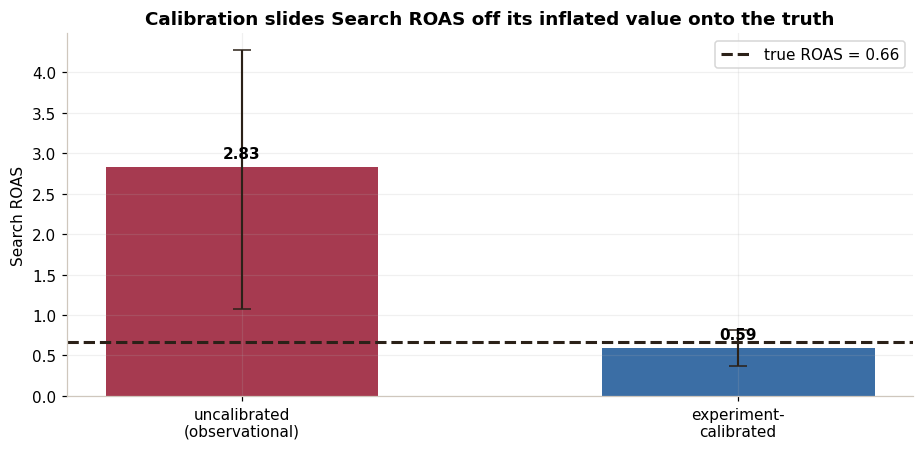

In [28]:
# CHART: before/after calibration Search ROI vs the true ROAS (with absolute-contribution HDI band,
# expressed as a ROAS band = Contribution HDI / Total Spend).
def roas_band(table, ch):
    spend = float(table.loc[ch, "Total Spend"])
    lo = float(table.loc[ch, "Contribution HDI Low"]) / spend
    hi = float(table.loc[ch, "Contribution HDI High"]) / spend
    mid = float(table.loc[ch, "ROI"])
    return mid, lo, hi

mu_u, lo_u, hi_u = roas_band(roi_table, "Search")
mu_c, lo_c, hi_c = roas_band(roi_cal_table, "Search")

fig, ax = plt.subplots(figsize=(8.5, 4.2))
xs = [0, 1]
labels = ["uncalibrated\n(observational)", "experiment-\ncalibrated"]
mids = [mu_u, mu_c]
errs = np.array([[mu_u - lo_u, mu_c - lo_c], [hi_u - mu_u, hi_c - mu_c]])
cols = [PALETTE["berry"], PALETTE["sky"]]
ax.bar(xs, mids, color=cols, width=0.55, yerr=errs, capsize=6,
       error_kw=dict(ecolor=INK, lw=1.4))
ax.axhline(true_search, color=INK, lw=2.0, ls="--", label=f"true ROAS = {true_search:.2f}")
for x, m in zip(xs, mids):
    ax.annotate(f"{m:.2f}", (x, m), textcoords="offset points", xytext=(0, 6),
                ha="center", fontsize=10, fontweight="bold")
ax.set_xticks(xs); ax.set_xticklabels(labels)
ax.set_ylabel("Search ROAS")
ax.set_title("Calibration slides Search ROAS off its inflated value onto the truth")
ax.legend(loc="upper right")
plt.tight_layout(); plt.show()

### What does the model *think* the experiment measured?

The likelihood route exposes a `Deterministic` named `{node}_model_estimand` — the model-implied estimand
the experiment is being compared against. For our Search ROAS experiment (index 0) the node is
`experiment_Search_roas_0_model_estimand`. Plotting its posterior against the measured value shows the
likelihood doing its job: the model's implied ROAS distribution is pulled to sit around the measured
0.66, with the spread reflecting the experiment's `se` and the rest of the data.

available *_model_estimand nodes: ['experiment_Search_roas_0_model_estimand']


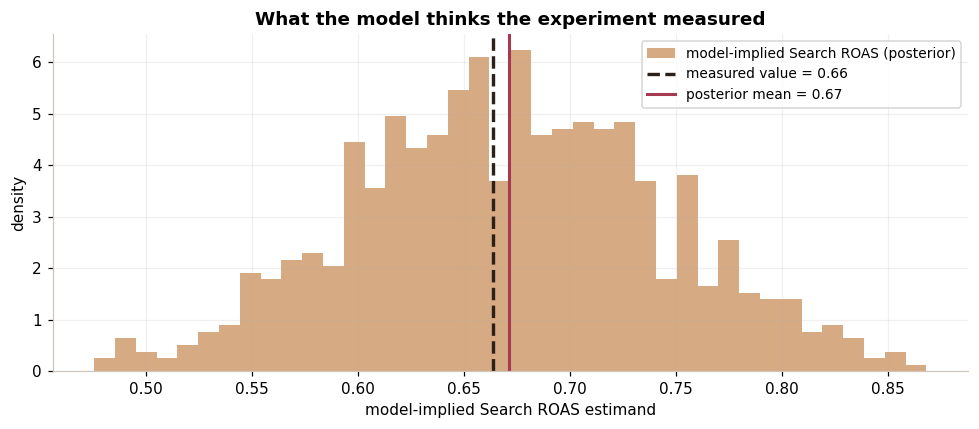

model-implied Search ROAS: mean 0.671  vs measured 0.664


In [29]:
# Pull the model-implied estimand Deterministic from the calibrated posterior.
post = m_cal._trace.posterior
estimand_node = "experiment_Search_roas_0_model_estimand"
have_node = estimand_node in post
print("available *_model_estimand nodes:", [v for v in post.data_vars if "model_estimand" in v])

if have_node:
    est_samples = np.asarray(post[estimand_node].values).reshape(-1)
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(est_samples, bins=40, color=ACCENT, alpha=0.55, density=True,
            label="model-implied Search ROAS (posterior)")
    ax.axvline(true_search, color=INK, lw=2.2, ls="--", label=f"measured value = {true_search:.2f}")
    ax.axvline(est_samples.mean(), color=PALETTE["berry"], lw=2.0,
               label=f"posterior mean = {est_samples.mean():.2f}")
    ax.set_xlabel("model-implied Search ROAS estimand"); ax.set_ylabel("density")
    ax.set_title("What the model thinks the experiment measured")
    ax.legend(fontsize=9)
    plt.tight_layout(); plt.show()
    print(f"model-implied Search ROAS: mean {est_samples.mean():.3f}  vs measured {true_search:.3f}")
else:
    print("estimand node not found under that name; skipping the estimand-vs-measured plot.")

In [30]:
# VERIFY (estimand-vs-measured -- DIRECTIONAL): the model-implied estimand is concentrated
# near the measured value (the likelihood pulled it there). Loose band: a 400-draw fit.
if have_node:
    em = est_samples.mean()
    assert em > 0, "ROAS estimand should be positive"
    assert abs(em - true_search) < 0.6, \
        f"model-implied ROAS {em:.3f} should sit near measured {true_search:.3f}"
    print(f"✓ model-implied Search ROAS mean {em:.3f} concentrated near measured {true_search:.3f}")
else:
    print("(estimand node unavailable -- check skipped)")

✓ model-implied Search ROAS mean 0.671 concentrated near measured 0.664


### Component sizes from the decomposition

For *component sizes* (as opposed to the time-series fit) the right view is a **bar chart of mean
contributions** from `compute_component_decomposition` — not a stacked area against the fit, which is
**not** additive to `predict()` (a naive stack gives a badly negative $R^2$). The decomposition confirms
that calibration mainly shrinks **Search's** contribution while leaving the baseline blocks alone.

,uncalibrated,calibrated
TV,12.5270,19.2715
Search,89.9584,18.7778
Social,26.9010,78.8482
Display,12.2318,19.1571


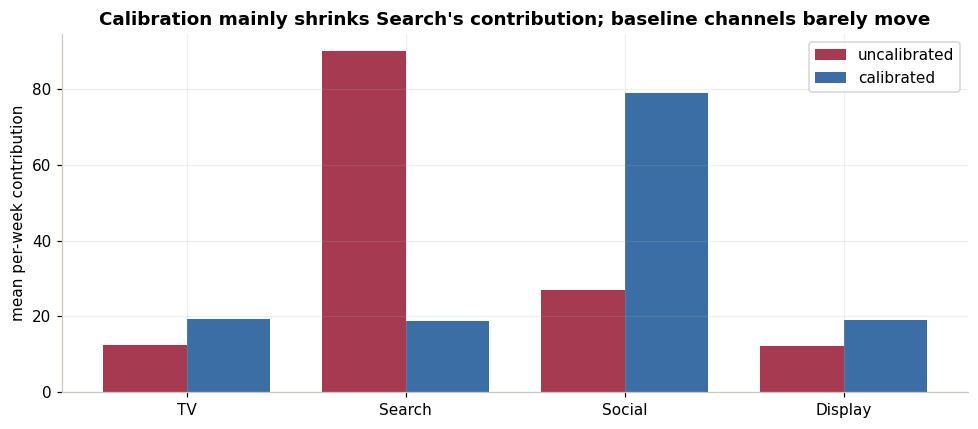

In [31]:
import pandas as pd
decomp_unc = mmm.compute_component_decomposition()
decomp_cal = m_cal.compute_component_decomposition()

# media_by_channel is a DataFrame (rows = obs/weeks, columns = channels) of mean contributions.
# Per-channel mean per-week contribution = mean over weeks of that channel's column.
def channel_means(decomp):
    return decomp.media_by_channel.reindex(columns=list(CHANNELS)).mean(axis=0)

cm_unc = channel_means(decomp_unc)
cm_cal = channel_means(decomp_cal)
comp = pd.DataFrame({"uncalibrated": cm_unc, "calibrated": cm_cal}).loc[list(CHANNELS)]
display(comp.round(4))

x = np.arange(len(CHANNELS)); w = 0.38
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - w/2, comp["uncalibrated"], w, color=PALETTE["berry"], label="uncalibrated")
ax.bar(x + w/2, comp["calibrated"], w, color=PALETTE["sky"], label="calibrated")
ax.set_xticks(x); ax.set_xticklabels(list(CHANNELS))
ax.set_ylabel("mean per-week contribution")
ax.set_title("Calibration mainly shrinks Search's contribution; baseline channels barely move")
ax.legend()
plt.tight_layout(); plt.show()

In [32]:
# VERIFY (decomposition -- DIRECTIONAL): Search's mean contribution drops under calibration,
# consistent with its ROI moving toward the (lower) truth.
assert comp.loc["Search", "calibrated"] < comp.loc["Search", "uncalibrated"], \
    "calibration should reduce Search's contribution"
print(f"✓ Search mean contribution: {comp.loc['Search','uncalibrated']:.4f} "
      f"-> {comp.loc['Search','calibrated']:.4f}  (shrunk by calibration)")

✓ Search mean contribution: 89.9584 -> 18.7778  (shrunk by calibration)


## Recap & what's next

**The two routes, reconciled:**

| | Route | The math | Updates | Estimands |
|---|---|---|---|---|
| **1** | prior (`ExperimentCalibrator`) | $\beta^{\text{target}}=\widehat L/K_c$, $K_c=\mathbb E[\text{contrib}/\beta]$ per draw, Gamma via $\alpha=(m/s)^2,\ \text{rate}=m/s^2$ | $\beta$ only (shape fixed) | contribution |
| **2** | likelihood (`ExperimentMeasurement`) | $\text{value}\sim\mathcal N(\text{estimand}(\theta),\text{se})$ | $\beta$, s-curve, **and** adstock — jointly | contribution / ROAS / mROAS |

**The three things to remember:**
1. Observational data only weakly identifies per-channel ROI — **equifinality** makes the
   (decay, saturation, $\beta$) ridge nearly flat. Controls help but are *not sufficient*.
2. A randomized experiment **breaks the trade-off** because contribution is **linear in $\beta_c$**
   ($\text{contribution}_c=\beta_c K_c$), so a measured lift inverts cleanly to a coefficient anchor —
   and the per-draw design factor $K_c$ is the bridge.
3. The **prior route** holds the s-curve / adstock shape fixed and encodes a contribution; the
   **likelihood route** updates $\beta$, the s-curve **and** the adstock jointly and supports ROAS/mROAS.
   On Aurora, either way Search's inflated ROI **slides onto the truth**.

**Earlier in the math series:**
- **`math_01_adstock.ipynb`** — carryover, and the equifinality recap we built on here.
- **`math_02_saturation.ipynb`** — the diminishing-returns curve $\mathrm{sat}(u)=1-e^{-\lambda u}$ that
  the design factor $K_c$ integrates over.